# Dataset expansion: Rashba + Dresselhaus + Unmatched

Pools three sets and runs three experiments:
1. regression on rashba + dresselhaus (splitting compounds only)
2. regression on all three (unmatched alpha = 0, zero-inflated)
3. classification: splits (rashba+dresselhaus) vs no-split (unmatched)

Transferable feature pool: E_pfrac_VBM/CBM (precomputed, all 3 sets), radius_mean and
elemental features (POSCAR), nb0 env descriptors (POSCAR), ehull (only if covered).
The k-path C6 features (pmid_afs_gauss_std, kpath_angle_deg) are NOT used: unmatched has
no Rashba k-path so they are undefined.

PREREQ: POSCAR_std must exist in the dresselhaus and unmatched folders. Run
reformat_poscars.py on those folders first (see chat for the one-line change + glob caveat).

## Cell 1: Config

In [1]:
import os
BASE_DIR = os.path.abspath("..")

# compound folders per set (each contains {Formula}-{uid}/POSCAR_std)
SET_DIRS = {
    "rashba":      os.path.join(BASE_DIR, "Inverse-design", "rashba"),
    "dresselhaus": os.path.join(BASE_DIR, "Inverse-design", "dresselhaus"),
    "unmatched":   os.path.join(BASE_DIR, "Inverse-design", "unmatched"),
}
# precomputed E_pfrac CSVs (uid, Formula, alpha_R, window, E_pfrac_VBM, E_pfrac_CBM)
DESC_DIR = os.path.join(BASE_DIR, "Weight-contribution", "contribution-model")
DESC_CSVS = {
    "rashba":      os.path.join(DESC_DIR, "desc_E_p1.0_rashba.csv"),
    "dresselhaus": os.path.join(DESC_DIR, "desc_E_p1.0_dresselhaus.csv"),
    "unmatched":   os.path.join(DESC_DIR, "desc_E_p1.0_unmatched.csv"),
}
# optional ehull sources (uid + ehull). add a third if you have one for unmatched.
EHULL_CSVS = [os.path.join(BASE_DIR, "Data", "rashba.csv"),
              os.path.join(BASE_DIR, "Data", "dresselhaus.csv")]

RESULTS_DIR = os.path.join(".", "expand-results")
os.makedirs(RESULTS_DIR, exist_ok=True)

print("PATH CHECK")
for k, p in {**{f"dir:{s}": d for s, d in SET_DIRS.items()},
             **{f"csv:{s}": c for s, c in DESC_CSVS.items()}}.items():
    print(f"  [{'OK' if os.path.exists(p) else 'MISSING'}] {k:18s} {p}")

PATH CHECK
  [OK] dir:rashba         c:\Users\AbCMS_Lab\Desktop\Keshav-DDP\Inverse-design\rashba
  [OK] dir:dresselhaus    c:\Users\AbCMS_Lab\Desktop\Keshav-DDP\Inverse-design\dresselhaus
  [OK] dir:unmatched      c:\Users\AbCMS_Lab\Desktop\Keshav-DDP\Inverse-design\unmatched
  [OK] csv:rashba         c:\Users\AbCMS_Lab\Desktop\Keshav-DDP\Weight-contribution\contribution-model\desc_E_p1.0_rashba.csv
  [OK] csv:dresselhaus    c:\Users\AbCMS_Lab\Desktop\Keshav-DDP\Weight-contribution\contribution-model\desc_E_p1.0_dresselhaus.csv
  [OK] csv:unmatched      c:\Users\AbCMS_Lab\Desktop\Keshav-DDP\Weight-contribution\contribution-model\desc_E_p1.0_unmatched.csv


## Cell 2: Imports

In [2]:
import glob
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
from pymatgen.core.structure import Structure
from pymatgen.core.periodic_table import Element
from scipy.special import spherical_jn
print("imports OK")

imports OK


## Cell 3: Build the master table (one row per uid)

alpha = max over a uid's appearances (unmatched forced to 0). is_split = 1 if the uid
appears in rashba or dresselhaus. E_pfrac is compound-level so any copy is fine.

In [3]:
parts = []
for s, csv in DESC_CSVS.items():
    c = pd.read_csv(csv)
    need = ["uid", "Formula", "alpha_R", "E_pfrac_VBM", "E_pfrac_CBM"]
    miss = [x for x in need if x not in c.columns]
    assert not miss, f"{s}: missing columns {miss}; has {list(c.columns)}"
    c = c[need].copy(); c["set"] = s
    if s == "unmatched":
        c["alpha_R"] = 0.0
    parts.append(c)
raw = pd.concat(parts, ignore_index=True)

g = raw.groupby("uid")
master = pd.DataFrame({
    "Formula":     g["Formula"].first(),
    "alpha":       g["alpha_R"].max(),
    "E_pfrac_VBM": g["E_pfrac_VBM"].first(),
    "E_pfrac_CBM": g["E_pfrac_CBM"].first(),
    "is_split":    g["set"].apply(lambda v: int(any(x in ("rashba", "dresselhaus") for x in v))),
    "sets":        g["set"].apply(lambda v: "+".join(sorted(set(v)))),
}).reset_index()

print("rows in each desc csv :", {s: int((raw["set"] == s).sum()) for s in DESC_CSVS})
print("unique uids (master)  :", len(master))
print("overlap rashba&dressel:", int((master["sets"] == "dresselhaus+rashba").sum()))
print("is_split balance      :", master["is_split"].value_counts().to_dict())
print(master.head(4).to_string(index=False))

rows in each desc csv : {'rashba': 99, 'dresselhaus': 25, 'unmatched': 77}
unique uids (master)  : 201
overlap rashba&dressel: 0
is_split balance      : {1: 124, 0: 77}
         uid Formula  alpha  E_pfrac_VBM  E_pfrac_CBM  is_split        sets
001dfe9a7fa2   ZrSe2  1.998     0.884882     0.082029         1 dresselhaus
001e03f2c095    SSeW  3.288     0.224009     0.194420         1      rashba
0155c4de2320   SnBr2  1.316     0.719395     0.890736         1 dresselhaus
01a2d5e89adc   Bi2I6  0.000     0.965231     0.956952         0   unmatched


## Cell 4: Descriptor parameters and bases (identical to nb0, so feature names match)

In [4]:
RC = 6.0
GAUSS_CENTERS = [2.0, 2.6, 3.2, 3.8, 4.4, 5.0]; GAUSS_SIGMA = 0.5
COS_K = [np.pi/RC*m for m in (1, 2, 3)]; BESSEL_K = np.pi/RC; BESSEL_N = [0, 1, 2]
AFS_MU, AFS_SIGMA = 2.8, 0.8; AFS_HARMONICS = [1, 2, 3]; AFS_RANG = 4.0; FIRST_SHELL = 3.5

def fc(r, rc=RC): return np.where(r <= rc, 0.5*(np.cos(np.pi*r/rc)+1.0), 0.0)
def b_gauss(r, mu, sig=GAUSS_SIGMA): return np.exp(-((r-mu)**2)/(2*sig**2))
def b_cos(r, k): return np.cos(k*r)
def b_bessel(r, n, k=BESSEL_K): return spherical_jn(n, k*r)
print("params set")

params set


## Cell 5: Periodic neighbour data (nb0)

In [5]:
def neighbor_data(s, rc=RC):
    alln = s.get_all_neighbors(rc); out = []
    for i, site in enumerate(s):
        ci = site.coords; zi = site.specie.Z; d=[]; v=[]; zj=[]
        for nb in alln[i]:
            dist = nb.nn_distance
            if dist <= 1e-3: continue
            d.append(dist); v.append(np.array(nb.coords)-ci); zj.append(nb.specie.Z)
        out.append(dict(zi=zi, d=np.array(d),
                        v=np.array(v) if v else np.zeros((0,3)), zj=np.array(zj)))
    return out
print("ok")

ok


## Cell 6: GRDF / AFS / simple geom (nb0) + elemental properties (nb5)

In [6]:
def grdf(nd, basis, weighted=False):
    per = []
    for a in nd:
        d = a["d"]
        if d.size == 0: per.append(0.0); continue
        w = basis(d)*fc(d)
        if weighted: w = w*np.sqrt(a["zi"]*a["zj"])
        per.append(float(w.sum()))
    per = np.array(per); return per.mean(), per.std()

def afs(nd):
    res = {m: [] for m in AFS_HARMONICS}
    for a in nd:
        d, v = a["d"], a["v"]; mask = d <= AFS_RANG; d, v = d[mask], v[mask]
        if d.size < 2:
            for m in AFS_HARMONICS: res[m].append(0.0)
            continue
        wr = np.exp(-((d-AFS_MU)**2)/(2*AFS_SIGMA**2))*fc(d)
        acc = {m: 0.0 for m in AFS_HARMONICS}
        for j in range(len(d)):
            for k in range(j+1, len(d)):
                c = np.clip(np.dot(v[j], v[k])/(d[j]*d[k]), -1, 1); th = np.arccos(c); ww = wr[j]*wr[k]
                for m in AFS_HARMONICS: acc[m] += ww*np.cos(m*th)
        for m in AFS_HARMONICS: res[m].append(acc[m])
    return {m: (np.array(res[m]).mean(), np.array(res[m]).std()) for m in AFS_HARMONICS}

def simple_geom(nd):
    coord=[]; bonds=[]; angles=[]
    for a in nd:
        d, v = a["d"], a["v"]; m = d <= FIRST_SHELL; coord.append(int(m.sum()))
        dd, vv = d[m], v[m]; bonds.extend(dd.tolist())
        for j in range(len(dd)):
            for k in range(j+1, len(dd)):
                c = np.clip(np.dot(vv[j], vv[k])/(dd[j]*dd[k]), -1, 1); angles.append(np.degrees(np.arccos(c)))
    coord=np.array(coord); bonds=np.array(bonds); angles=np.array(angles)
    return dict(coord_num=coord.mean(),
                bond_mean=bonds.mean() if bonds.size else 0.0, bond_std=bonds.std() if bonds.size else 0.0,
                angle_mean=angles.mean() if angles.size else 0.0, angle_std=angles.std() if angles.size else 0.0)

def elemental_props(s):
    els = list(set(s.species)); zs=[e.Z for e in els]; ms=[float(e.atomic_mass) for e in els]
    rad=[float(e.atomic_radius) if e.atomic_radius else 1.0 for e in els]
    return dict(max_Z=max(zs), max_Z4=max(z**4 for z in zs), max_mass=max(ms),
                radius_mean=np.mean(rad), radius_diff=(max(rad)-min(rad)) if len(rad)>1 else 0.0,
                n_elements=len(els), mean_Z=np.mean(zs), sum_Z4=sum(z**4 for z in zs))
print("descriptor fns ready")

descriptor fns ready


## Cell 7: Find folders, load POSCAR_std, extract features for all uids

Reports per set how many uids resolved to a folder and how many had POSCAR_std. If a set
shows missing POSCAR_std, run reformat_poscars.py on that folder before continuing.

In [7]:
def find_folder(uid, vasp_dir):
    for folder in glob.glob(os.path.join(vasp_dir, "*")):
        name = os.path.basename(folder); idx = name.rfind("-")
        if idx != -1 and name[idx+1:] == uid:
            return folder
    return None

def load_std(folder):
    p = os.path.join(folder, "POSCAR_std")
    return Structure.from_file(p) if os.path.exists(p) else None

# map each uid to its set's directory (a uid in both rashba & dresselhaus -> rashba dir)
def dir_for(row):
    s = row["sets"]
    if "rashba" in s: return SET_DIRS["rashba"]
    if "dresselhaus" in s: return SET_DIRS["dresselhaus"]
    return SET_DIRS["unmatched"]

recs = []; no_folder = []; no_std = []
for _, row in master.iterrows():
    uid = row["uid"]; vdir = dir_for(row)
    folder = find_folder(uid, vdir)
    if folder is None: no_folder.append((row["sets"], uid)); continue
    s = load_std(folder)
    if s is None: no_std.append((row["sets"], uid)); continue
    nd = neighbor_data(s); feat = {"uid": uid}
    for mu in GAUSS_CENTERS:
        feat[f"grdf_gauss_{mu:.1f}_mean"], feat[f"grdf_gauss_{mu:.1f}_std"] = grdf(nd, lambda r, mu=mu: b_gauss(r, mu))
        feat[f"zw_grdf_gauss_{mu:.1f}_mean"], feat[f"zw_grdf_gauss_{mu:.1f}_std"] = grdf(nd, lambda r, mu=mu: b_gauss(r, mu), weighted=True)
    for i, k in enumerate(COS_K, 1):
        feat[f"grdf_cos_k{i}_mean"], feat[f"grdf_cos_k{i}_std"] = grdf(nd, lambda r, k=k: b_cos(r, k))
    for n in BESSEL_N:
        feat[f"grdf_bessel_n{n}_mean"], feat[f"grdf_bessel_n{n}_std"] = grdf(nd, lambda r, n=n: b_bessel(r, n))
    a = afs(nd)
    for m in AFS_HARMONICS: feat[f"afs_m{m}_mean"], feat[f"afs_m{m}_std"] = a[m]
    feat.update(simple_geom(nd)); feat.update(elemental_props(s))
    recs.append(feat)

df_feat = pd.DataFrame(recs)
print(f"feature rows: {len(df_feat)} / {len(master)} uids")
print("no folder found :", len(no_folder), no_folder[:5])
print("no POSCAR_std   :", len(no_std), no_std[:8])
df_feat.to_csv(os.path.join(RESULTS_DIR, "expand_features.csv"), index=False)

feature rows: 200 / 201 uids
no folder found : 0 []
no POSCAR_std   : 1 [('unmatched', '29ae3f5ef5a7')]


## Cell 8: Assemble work table, attach ehull if fully covered, define the pool

In [8]:
work = master.merge(df_feat, on="uid")
print(f"work table: {len(work)} compounds")

# optional ehull
eh = None
for csv in EHULL_CSVS:
    if os.path.exists(csv):
        t = pd.read_csv(csv)
        if "uid" in t.columns and "ehull" in t.columns:
            eh = t[["uid", "ehull"]] if eh is None else pd.concat([eh, t[["uid", "ehull"]]])
if eh is not None:
    eh = eh.drop_duplicates("uid")
    work = work.merge(eh, on="uid", how="left")
    cov = work["ehull"].notna().mean()
    print(f"ehull coverage: {cov:.0%}")
else:
    print("no ehull source found")

GUARANTEED = ["E_pfrac_VBM", "E_pfrac_CBM", "radius_mean"]
ENV_POOL = [c for c in df_feat.columns if c not in ("uid", "radius_mean")]
print(f"guaranteed: {GUARANTEED}")
print(f"env/elemental pool: {len(ENV_POOL)} features")

work table: 200 compounds
ehull coverage: 62%
guaranteed: ['E_pfrac_VBM', 'E_pfrac_CBM', 'radius_mean']
env/elemental pool: 54 features


## Cell 9: Modeling helpers (XGB, forward selection, LOO confirm)

In [9]:
from sklearn.model_selection import LeaveOneOut, KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, f1_score, roc_auc_score, accuracy_score
from xgboost import XGBRegressor, XGBClassifier

XGB_REG_PARAMS = dict(n_estimators=100, max_depth=3, learning_rate=0.1, subsample=0.8,
                      colsample_bytree=0.8, reg_alpha=1.0, reg_lambda=1.0, random_state=42, verbosity=0)
_kf = KFold(n_splits=5, shuffle=True, random_state=42)

def _reg_cv(frame, feats, y, cv): 
    X = frame[feats].fillna(0).values
    return cross_val_predict(XGBRegressor(**XGB_REG_PARAMS), X, y, cv=cv)

def reg_report(frame, feats, y, label):
    yp5 = _reg_cv(frame, feats, y, _kf); yl = _reg_cv(frame, feats, y, LeaveOneOut())
    print(f"  {label:22s} 5fold R2={r2_score(y,yp5):.3f}  LOO R2={r2_score(y,yl):.3f}  LOO MAE={mean_absolute_error(y,yl):.3f}")
    return r2_score(y, yl)

def reg_forward(frame, y, pool, seed, upto):
    chosen = list(seed)
    while len(chosen) < upto:
        cand = sorted(((r2_score(y, _reg_cv(frame, chosen+[f], y, _kf)), f) for f in pool if f not in chosen), reverse=True)
        chosen.append(cand[0][1])
    return chosen

def clf_report(frame, feats, y, label):
    X = frame[feats].fillna(0).values
    spw = (y==0).sum()/max((y==1).sum(),1)
    clf = XGBClassifier(**XGB_REG_PARAMS, scale_pos_weight=spw)
    yp = cross_val_predict(clf, X, y, cv=_kf)
    pp = cross_val_predict(clf, X, y, cv=_kf, method="predict_proba")[:,1]
    print(f"  {label:22s} ACC={accuracy_score(y,yp):.3f}  F1={f1_score(y,yp):.3f}  AUC={roc_auc_score(y,pp):.3f}")
    return roc_auc_score(y, pp)
print("helpers ready")

helpers ready


## Cell 10: Experiment 1 - regression on rashba + dresselhaus (splitting only)

In [10]:
sub = work[work["is_split"] == 1].reset_index(drop=True)
y = sub["alpha"].values
print(f"n = {len(sub)} splitting compounds")
reg_report(sub, GUARANTEED, y, "guaranteed (3)")
chosen = reg_forward(sub, y, ENV_POOL, GUARANTEED, upto=8)
for n in range(len(GUARANTEED), len(chosen)+1):
    reg_report(sub, chosen[:n], y, f"+env -> {n} feat")
print("final set:", chosen)

n = 124 splitting compounds
  guaranteed (3)         5fold R2=0.380  LOO R2=0.374  LOO MAE=0.606
  +env -> 3 feat         5fold R2=0.380  LOO R2=0.374  LOO MAE=0.606
  +env -> 4 feat         5fold R2=0.542  LOO R2=0.538  LOO MAE=0.548
  +env -> 5 feat         5fold R2=0.609  LOO R2=0.583  LOO MAE=0.530
  +env -> 6 feat         5fold R2=0.634  LOO R2=0.628  LOO MAE=0.483
  +env -> 7 feat         5fold R2=0.652  LOO R2=0.614  LOO MAE=0.495
  +env -> 8 feat         5fold R2=0.652  LOO R2=0.647  LOO MAE=0.464
final set: ['E_pfrac_VBM', 'E_pfrac_CBM', 'radius_mean', 'angle_mean', 'zw_grdf_gauss_3.2_mean', 'bond_mean', 'grdf_cos_k1_mean', 'grdf_gauss_3.8_std']


## Cell 11: Experiment 2 - regression on all three (unmatched alpha = 0)

In [11]:
y = work["alpha"].values
print(f"n = {len(work)} (zeros = {(y==0).sum()})")
reg_report(work, GUARANTEED, y, "guaranteed (3)")
chosen = reg_forward(work, y, ENV_POOL, GUARANTEED, upto=8)
for n in range(len(GUARANTEED), len(chosen)+1):
    reg_report(work, chosen[:n], y, f"+env -> {n} feat")
print("note: zero-inflated; read alongside exp 3")

n = 200 (zeros = 76)
  guaranteed (3)         5fold R2=0.278  LOO R2=0.316  LOO MAE=0.705
  +env -> 3 feat         5fold R2=0.278  LOO R2=0.316  LOO MAE=0.705
  +env -> 4 feat         5fold R2=0.463  LOO R2=0.496  LOO MAE=0.618
  +env -> 5 feat         5fold R2=0.525  LOO R2=0.542  LOO MAE=0.602
  +env -> 6 feat         5fold R2=0.583  LOO R2=0.586  LOO MAE=0.556
  +env -> 7 feat         5fold R2=0.598  LOO R2=0.618  LOO MAE=0.543
  +env -> 8 feat         5fold R2=0.639  LOO R2=0.662  LOO MAE=0.498
note: zero-inflated; read alongside exp 3


## Cell 12: Experiment 3 - classification, splits vs no-split

In [12]:
y = work["is_split"].values
print(f"n = {len(work)}  positives (split) = {int(y.sum())}  negatives (unmatched) = {int((y==0).sum())}")
clf_report(work, GUARANTEED, y, "guaranteed (3)")
# forward add by AUC
chosen = list(GUARANTEED)
while len(chosen) < 8:
    best = None
    for f in ENV_POOL:
        if f in chosen: continue
        X = work[chosen+[f]].fillna(0).values
        spw = (y==0).sum()/max((y==1).sum(),1)
        pp = cross_val_predict(XGBClassifier(**XGB_REG_PARAMS, scale_pos_weight=spw), X, y, cv=_kf, method="predict_proba")[:,1]
        au = roc_auc_score(y, pp)
        if best is None or au > best[0]: best = (au, f)
    chosen.append(best[1])
for n in range(len(GUARANTEED), len(chosen)+1):
    clf_report(work, chosen[:n], y, f"+env -> {n} feat")
print("final set:", chosen)

n = 200  positives (split) = 124  negatives (unmatched) = 76
  guaranteed (3)         ACC=0.805  F1=0.845  AUC=0.854
  +env -> 3 feat         ACC=0.805  F1=0.845  AUC=0.854
  +env -> 4 feat         ACC=0.865  F1=0.892  AUC=0.910
  +env -> 5 feat         ACC=0.890  F1=0.913  AUC=0.929
  +env -> 6 feat         ACC=0.905  F1=0.924  AUC=0.956
  +env -> 7 feat         ACC=0.915  F1=0.931  AUC=0.970
  +env -> 8 feat         ACC=0.920  F1=0.935  AUC=0.975
final set: ['E_pfrac_VBM', 'E_pfrac_CBM', 'radius_mean', 'zw_grdf_gauss_5.0_mean', 'bond_std', 'zw_grdf_gauss_3.8_mean', 'coord_num', 'grdf_gauss_5.0_std']


In [13]:
# ============================================================
# Diagnostics for the splits-vs-no-split classifier (exp 3).
# Run AFTER cells 8-9 of nb_expand_dataset (needs `work`, XGB_REG_PARAMS).
# Answers: (1) is 0.975 stable across seeds + under LOO?
#          (2) is it structure, or just a heavy-element detector?
#          (3) does AUC collapse to ~0.5 when labels are shuffled?
# ============================================================
import numpy as np
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_predict
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from xgboost import XGBClassifier

y = work["is_split"].values
present = lambda lst: [c for c in lst if c in work.columns]

EPFRAC    = present(["E_pfrac_VBM", "E_pfrac_CBM"])
ELEMENTAL = present(["max_Z","max_Z4","max_mass","radius_mean","radius_diff","n_elements","mean_Z","sum_Z4"])
ZW        = present([c for c in work.columns if c.startswith("zw_")])
GEOM      = present([c for c in work.columns
                     if (c.startswith("grdf_") and not c.startswith("zw_"))
                     or c.startswith("afs_")
                     or c in ("coord_num","bond_mean","bond_std","angle_mean","angle_std")])
FINAL8    = present(["E_pfrac_VBM","E_pfrac_CBM","radius_mean","zw_grdf_gauss_5.0_mean",
                     "bond_std","zw_grdf_gauss_3.8_mean","coord_num","grdf_gauss_5.0_std"])

GROUPS = {
    "final 8 (chosen)":     FINAL8,
    "guaranteed 3":         present(["E_pfrac_VBM","E_pfrac_CBM","radius_mean"]),
    "geometry only (pure)": GEOM,
    "Z-weighted only":      ZW,
    "elemental only":       ELEMENTAL,
    "E_pfrac only":         EPFRAC,
}
print("group sizes:", {k: len(v) for k, v in GROUPS.items()})
print(f"n={len(y)}  positives(split)={int(y.sum())}  negatives(no-split)={int((y==0).sum())}\n")

spw = (y==0).sum() / max((y==1).sum(), 1)

def auc_cv(feats, seed):
    X = work[feats].fillna(0).values
    clf = XGBClassifier(**{**XGB_REG_PARAMS, "random_state": seed}, scale_pos_weight=spw)
    pp = cross_val_predict(clf, X, y, cv=KFold(5, shuffle=True, random_state=seed), method="predict_proba")[:, 1]
    return roc_auc_score(y, pp)

def auc_loo(feats):
    X = work[feats].fillna(0).values
    clf = XGBClassifier(**XGB_REG_PARAMS, scale_pos_weight=spw)
    pp = cross_val_predict(clf, X, y, cv=LeaveOneOut(), method="predict_proba")[:, 1]
    return roc_auc_score(y, pp)

SEEDS = [0, 1, 2, 7, 42]
print(f"{'group':22s} {'5fold AUC mean+-sd':22s} {'LOO AUC':>8}")
for name, feats in GROUPS.items():
    if not feats:
        print(f"{name:22s} (empty, skipped)"); continue
    a = [auc_cv(feats, s) for s in SEEDS]
    print(f"{name:22s} {np.mean(a):.3f} +- {np.std(a):.3f}        {auc_loo(feats):8.3f}")

# honest headline for the chosen set, LOO
X = work[FINAL8].fillna(0).values
proba = cross_val_predict(XGBClassifier(**XGB_REG_PARAMS, scale_pos_weight=spw), X, y,
                          cv=LeaveOneOut(), method="predict_proba")[:, 1]
pred = (proba >= 0.5).astype(int)
print(f"\nfinal 8, LOO: ACC={accuracy_score(y,pred):.3f}  F1={f1_score(y,pred):.3f}  AUC={roc_auc_score(y,proba):.3f}")

# leakage control: shuffle labels, AUC should fall to ~0.5
rng = np.random.default_rng(0); sh = []
for _ in range(10):
    yp = rng.permutation(y); sp = (yp==0).sum()/max((yp==1).sum(),1)
    pp = cross_val_predict(XGBClassifier(**{**XGB_REG_PARAMS,"random_state":0}, scale_pos_weight=sp),
                           work[FINAL8].fillna(0).values, yp, cv=KFold(5,shuffle=True,random_state=0),
                           method="predict_proba")[:, 1]
    sh.append(roc_auc_score(yp, pp))
print(f"shuffled-label control (final 8): AUC={np.mean(sh):.3f} +- {np.std(sh):.3f}  (want ~0.5)")

group sizes: {'final 8 (chosen)': 8, 'guaranteed 3': 3, 'geometry only (pure)': 35, 'Z-weighted only': 12, 'elemental only': 8, 'E_pfrac only': 2}
n=200  positives(split)=124  negatives(no-split)=76

group                  5fold AUC mean+-sd      LOO AUC
final 8 (chosen)       0.967 +- 0.006           0.972
guaranteed 3           0.850 +- 0.006           0.859
geometry only (pure)   0.932 +- 0.005           0.945
Z-weighted only        0.878 +- 0.004           0.889
elemental only         0.804 +- 0.019           0.826
E_pfrac only           0.849 +- 0.009           0.847

final 8, LOO: ACC=0.910  F1=0.926  AUC=0.972
shuffled-label control (final 8): AUC=0.533 +- 0.037  (want ~0.5)


In [14]:
# ===== CELL A: comprehensive analysis (run after the cells that build `work`) =====
import numpy as np, pandas as pd, os
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_predict
from sklearn.metrics import (roc_auc_score, roc_curve, f1_score, accuracy_score,
                             precision_score, recall_score, confusion_matrix)
from xgboost import XGBClassifier

RESULTS_DIR = os.path.join(".", "expand-results"); os.makedirs(RESULTS_DIR, exist_ok=True)
ID_COLS = ["uid","Formula","sets","alpha","is_split"]
y = work["is_split"].values
present = lambda lst: [c for c in lst if c in work.columns]

EPFRAC    = present(["E_pfrac_VBM","E_pfrac_CBM"])
ELEMENTAL = present(["max_Z","max_Z4","max_mass","radius_mean","radius_diff","n_elements","mean_Z","sum_Z4"])
ZW        = present([c for c in work.columns if c.startswith("zw_")])
GEOM      = present([c for c in work.columns if (c.startswith("grdf_") and not c.startswith("zw_"))
                     or c.startswith("afs_") or c in ("coord_num","bond_mean","bond_std","angle_mean","angle_std")])
FINAL8    = present(["E_pfrac_VBM","E_pfrac_CBM","radius_mean","zw_grdf_gauss_5.0_mean",
                     "bond_std","zw_grdf_gauss_3.8_mean","coord_num","grdf_gauss_5.0_std"])
FULL_POOL = [c for c in work.columns if c not in ID_COLS]

GROUPS = {"Full (8 feat)":FINAL8, "Guaranteed (E_pfrac+radius)":present(["E_pfrac_VBM","E_pfrac_CBM","radius_mean"]),
          "Geometry only":GEOM, "Z-weighted only":ZW, "Elemental only":ELEMENTAL, "E_pfrac only":EPFRAC}
spw = (y==0).sum()/max((y==1).sum(),1); SEEDS=[0,1,2,7,42]

def proba_loo(feats):
    X=work[feats].fillna(0).values
    return cross_val_predict(XGBClassifier(**XGB_REG_PARAMS,scale_pos_weight=spw),X,y,cv=LeaveOneOut(),method="predict_proba")[:,1]
def auc_cv(feats,seed):
    X=work[feats].fillna(0).values
    return roc_auc_score(y,cross_val_predict(XGBClassifier(**{**XGB_REG_PARAMS,"random_state":seed},scale_pos_weight=spw),
                         X,y,cv=KFold(5,shuffle=True,random_state=seed),method="predict_proba")[:,1])

group_proba={}; rows=[]
for name,feats in GROUPS.items():
    if not feats: continue
    p=proba_loo(feats); group_proba[name]=p; a5=[auc_cv(feats,s) for s in SEEDS]; pred=(p>=0.5).astype(int)
    rows.append(dict(group=name,n_feat=len(feats),auc_loo=roc_auc_score(y,p),auc_5f_mean=np.mean(a5),auc_5f_sd=np.std(a5),
                     acc=accuracy_score(y,pred),f1=f1_score(y,pred),precision=precision_score(y,pred),recall=recall_score(y,pred)))
res=pd.DataFrame(rows).sort_values("auc_loo",ascending=False).reset_index(drop=True)
res.to_csv(os.path.join(RESULTS_DIR,"classifier_group_metrics.csv"),index=False)

rng=np.random.default_rng(0); sh=[]
for _ in range(20):
    yp=rng.permutation(y); sp=(yp==0).sum()/max((yp==1).sum(),1)
    pp=cross_val_predict(XGBClassifier(**{**XGB_REG_PARAMS,"random_state":0},scale_pos_weight=sp),
       work[FINAL8].fillna(0).values,yp,cv=KFold(5,shuffle=True,random_state=0),method="predict_proba")[:,1]
    sh.append(roc_auc_score(yp,pp))
shuffle_auc=(np.mean(sh),np.std(sh))

def auc_cv_quick(feats):
    X=work[feats].fillna(0).values
    return roc_auc_score(y,cross_val_predict(XGBClassifier(**XGB_REG_PARAMS,scale_pos_weight=spw),
                         X,y,cv=KFold(5,shuffle=True,random_state=42),method="predict_proba")[:,1])
chosen=[]; abl=[]
while len(chosen)<8:
    cand=sorted(((auc_cv_quick(chosen+[f]),f) for f in FULL_POOL if f not in chosen),reverse=True)
    chosen.append(cand[0][1]); abl.append((len(chosen),cand[0][1],cand[0][0]))
abl_df=pd.DataFrame(abl,columns=["n","added","auc_5f"]); abl_df.to_csv(os.path.join(RESULTS_DIR,"ablation_forward.csv"),index=False)

imp_clf=XGBClassifier(**{**XGB_REG_PARAMS,"importance_type":"gain"},scale_pos_weight=spw)
imp_clf.fit(work[FINAL8].fillna(0).values,y)
imp=pd.Series(imp_clf.feature_importances_,index=FINAL8).sort_values(ascending=False)

pf=(group_proba["Full (8 feat)"]>=0.5).astype(int)
mis=work.loc[pf!=y,["Formula","uid","sets","alpha","is_split"]].copy()
mis["pred"]=pf[pf!=y]; mis["proba"]=group_proba["Full (8 feat)"][pf!=y]
mis.to_csv(os.path.join(RESULTS_DIR,"misclassified.csv"),index=False)
cm=confusion_matrix(y,pf)

g=res.set_index("group")
print("="*70); print("  SPIN-SPLITTING PRESENCE CLASSIFIER  -  RESULTS SUMMARY"); print("="*70)
print(f"""
DATASET  (Nascimento et al., Sci. Data 9, 195, 2022)
  {len(y)} 2D compounds | positive (splitting, Rashba+Dresselhaus) = {int(y.sum())} | negative (no SS) = {int((y==0).sum())}
  All share: non-magnetic, non-centrosymmetric, finite-gap semiconductor
  -> the negative class is matched to positives on magnetism, symmetry, and gap.

FEATURES
  Structural (POSCAR only): periodic-neighbour GRDF (Gaussian/cosine/Bessel) + AFS + simple geometry,
    Rc=6 A, per-atom normalised; Z-weighted variants scale pairs by sqrt(Zi*Zj).
  + band-edge p-orbital fraction (E_pfrac_VBM/CBM) and radius_mean.

PROTOCOL
  XGBoost (depth 3, 100 trees), class-balanced (scale_pos_weight={spw:.2f}).
  Leave-one-out AUC, plus 5-fold AUC averaged over seeds {SEEDS}.

RESULTS BY FEATURE GROUP (LOO AUC, sorted)""")
print(res.to_string(index=False, formatters={c:(lambda v:f"{v:.3f}") for c in
      ["auc_loo","auc_5f_mean","auc_5f_sd","acc","f1","precision","recall"]}))
print(f"""
CONTROLS
  Shuffled-label AUC (final 8): {shuffle_auc[0]:.3f} +- {shuffle_auc[1]:.3f}  (chance ~0.50 -> no CV leakage)
  Confusion matrix (final 8, LOO)   rows=true, cols=pred
            pred_no  pred_yes
    no       {cm[0,0]:4d}     {cm[0,1]:4d}
    yes      {cm[1,0]:4d}     {cm[1,1]:4d}

KEY FINDINGS
  1. STRUCTURE ALONE (no element identity, no E_pfrac) -> LOO AUC {g.loc['Geometry only','auc_loo']:.3f},
     well above the elemental-only heavy-vs-light baseline ({g.loc['Elemental only','auc_loo']:.3f}).
     The classifier reads local geometry, not just atomic number.
  2. Full 8-feature model -> LOO AUC {g.loc['Full (8 feat)','auc_loo']:.3f}, F1 {g.loc['Full (8 feat)','f1']:.3f}, stable across seeds (sd {g.loc['Full (8 feat)','auc_5f_sd']:.3f}).
  3. E_pfrac (needs DFT DOS) adds little over geometry -> structure-only screening is viable
     without band-structure calculations.

TOP FEATURES (XGBoost gain, final 8)""")
print(imp.to_string(float_format=lambda v:f"{v:.3f}"))
print(f"""
MISCLASSIFIED: {len(mis)} / {len(y)}  (saved to misclassified.csv -- inspect these for the physics discussion)

CAVEATS
  - Negative set is small ({int((y==0).sum())}); quote the seed spread, not a single split.
  - SOC ~ Z^4, so part of the signal is heavy-element; the geometry-only test shows it is
    not the whole story, but state the contribution honestly.
  - Negative class = "no SS identified" compounds, NOT an alpha<0.1 cut on Rashba materials.
    Confirm with the advisor which definition the task requires.

  saved: classifier_group_metrics.csv, ablation_forward.csv, misclassified.csv""")

  SPIN-SPLITTING PRESENCE CLASSIFIER  -  RESULTS SUMMARY

DATASET  (Nascimento et al., Sci. Data 9, 195, 2022)
  200 2D compounds | positive (splitting, Rashba+Dresselhaus) = 124 | negative (no SS) = 76
  All share: non-magnetic, non-centrosymmetric, finite-gap semiconductor
  -> the negative class is matched to positives on magnetism, symmetry, and gap.

FEATURES
  Structural (POSCAR only): periodic-neighbour GRDF (Gaussian/cosine/Bessel) + AFS + simple geometry,
    Rc=6 A, per-atom normalised; Z-weighted variants scale pairs by sqrt(Zi*Zj).
  + band-edge p-orbital fraction (E_pfrac_VBM/CBM) and radius_mean.

PROTOCOL
  XGBoost (depth 3, 100 trees), class-balanced (scale_pos_weight=0.61).
  Leave-one-out AUC, plus 5-fold AUC averaged over seeds [0, 1, 2, 7, 42].

RESULTS BY FEATURE GROUP (LOO AUC, sorted)
                      group  n_feat auc_loo auc_5f_mean auc_5f_sd   acc    f1 precision recall
              Full (8 feat)       8   0.972       0.967     0.006 0.910 0.926     0.94

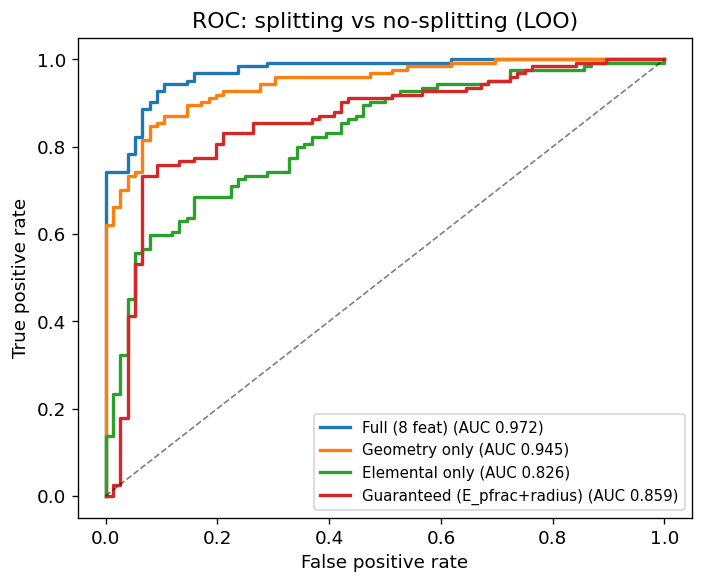

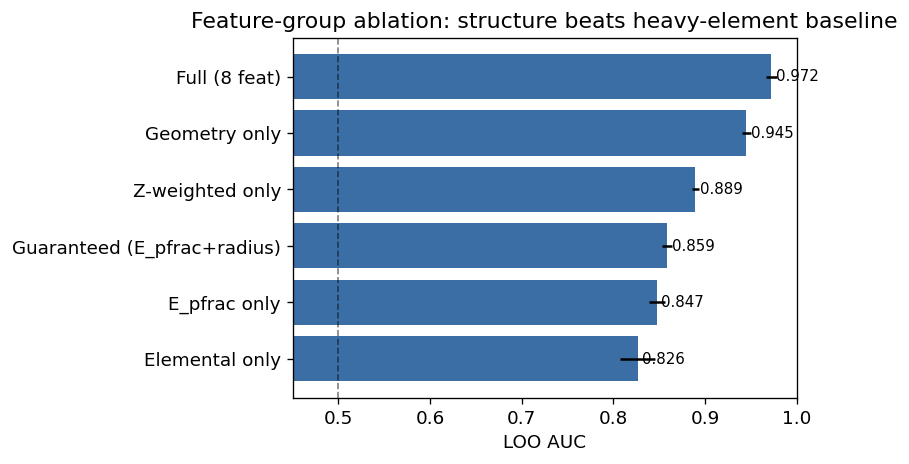

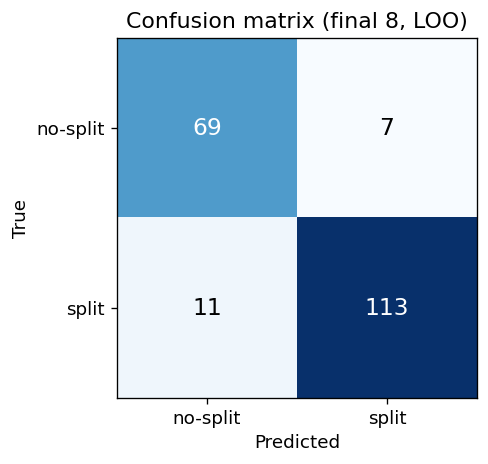

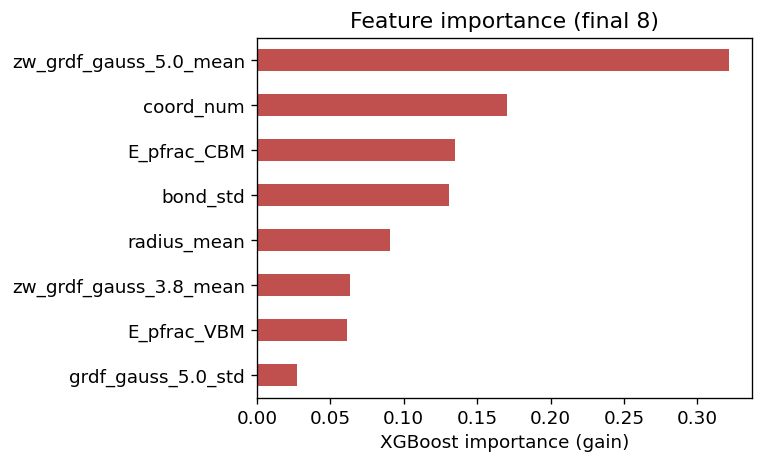

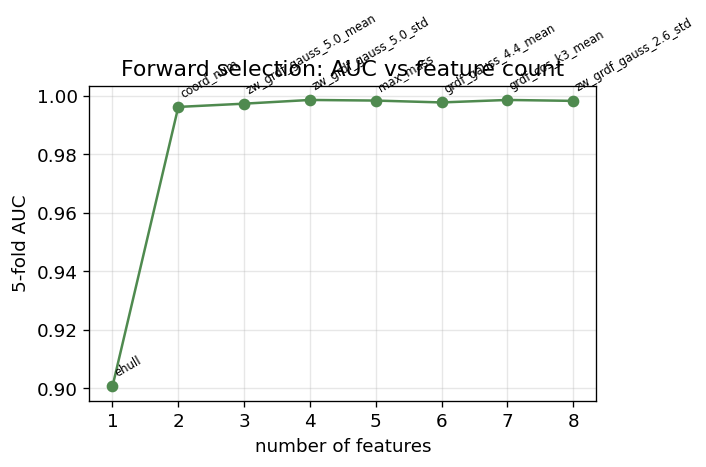

saved 5 figures + 3 CSVs to .\expand-results


In [15]:
# ===== CELL B: report figures (run after Cell A) =====
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":120,"savefig.dpi":300,"font.size":11})

fig,ax=plt.subplots(figsize=(6,5))
for name in ["Full (8 feat)","Geometry only","Elemental only","Guaranteed (E_pfrac+radius)"]:
    if name in group_proba:
        fpr,tpr,_=roc_curve(y,group_proba[name])
        ax.plot(fpr,tpr,lw=2,label=f"{name} (AUC {roc_auc_score(y,group_proba[name]):.3f})")
ax.plot([0,1],[0,1],"k--",lw=1,alpha=.5); ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC: splitting vs no-splitting (LOO)"); ax.legend(loc="lower right",fontsize=9)
fig.tight_layout(); fig.savefig(os.path.join(RESULTS_DIR,"fig_roc.png")); plt.show()

fig,ax=plt.subplots(figsize=(7,4)); r=res.sort_values("auc_loo")
ax.barh(r["group"],r["auc_loo"],xerr=r["auc_5f_sd"],color="#3b6ea5")
for i,v in enumerate(r["auc_loo"]): ax.text(v+0.005,i,f"{v:.3f}",va="center",fontsize=9)
ax.axvline(0.5,color="k",ls="--",lw=1,alpha=.5); ax.set_xlim(0.45,1.0); ax.set_xlabel("LOO AUC")
ax.set_title("Feature-group ablation: structure beats heavy-element baseline")
fig.tight_layout(); fig.savefig(os.path.join(RESULTS_DIR,"fig_group_auc.png")); plt.show()

fig,ax=plt.subplots(figsize=(4.2,4)); ax.imshow(cm,cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j,i,cm[i,j],ha="center",va="center",fontsize=14,color="white" if cm[i,j]>cm.max()/2 else "black")
ax.set_xticks([0,1]); ax.set_xticklabels(["no-split","split"]); ax.set_yticks([0,1]); ax.set_yticklabels(["no-split","split"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion matrix (final 8, LOO)")
fig.tight_layout(); fig.savefig(os.path.join(RESULTS_DIR,"fig_confusion.png")); plt.show()

fig,ax=plt.subplots(figsize=(6.5,4)); imp.sort_values().plot.barh(ax=ax,color="#c0504d")
ax.set_xlabel("XGBoost importance (gain)"); ax.set_title("Feature importance (final 8)")
fig.tight_layout(); fig.savefig(os.path.join(RESULTS_DIR,"fig_importance.png")); plt.show()

fig,ax=plt.subplots(figsize=(6,4)); ax.plot(abl_df["n"],abl_df["auc_5f"],"o-",color="#4f8a4f")
for _,row in abl_df.iterrows():
    ax.annotate(row["added"],(row["n"],row["auc_5f"]),fontsize=7,rotation=30,xytext=(0,6),textcoords="offset points")
ax.set_xlabel("number of features"); ax.set_ylabel("5-fold AUC"); ax.set_title("Forward selection: AUC vs feature count")
ax.grid(alpha=.3); fig.tight_layout(); fig.savefig(os.path.join(RESULTS_DIR,"fig_ablation.png")); plt.show()

print("saved 5 figures + 3 CSVs to", RESULTS_DIR)